### Importing Libraries and Data


In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score

In [91]:
diabetes_data = pd.read_csv('/content/drive/MyDrive/ML datasets/diabetes.csv')
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [92]:
diabetes_data.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### Preprocessing

In [93]:
# defining target and feature variables
x = diabetes_data.drop(columns = ['Outcome'])
y = diabetes_data['Outcome']

# standardizing
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [94]:
# Variance explained by PCA
pca  = PCA().fit(x_scaled)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
variance_table = pd.DataFrame({
    'principle component':[f'PC{i}' for i in range(1, len(cumulative_variance) + 1)],
    'variance explained by PCA(%)': np.round(pca.explained_variance_ratio_, 4) * 100,
    'cumulative variance(%)': np.round(cumulative_variance, 4) * 100
})

print(variance_table)

  principle component  variance explained by PCA(%)  cumulative variance(%)
0                 PC1                         26.18                   26.18
1                 PC2                         21.64                   47.82
2                 PC3                         12.87                   60.69
3                 PC4                         10.94                   71.63
4                 PC5                          9.53                   81.16
5                 PC6                          8.53                   89.70
6                 PC7                          5.25                   94.94
7                 PC8                          5.06                  100.00


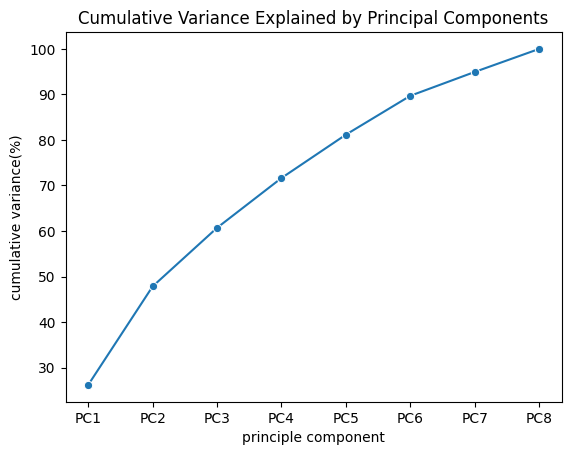

In [95]:
sns.lineplot(x = 'principle component', y = 'cumulative variance(%)', data = variance_table, marker = 'o')
plt.title('Cumulative Variance Explained by Principal Components')
plt.show()

first 5 components explains around 81% of the total variability.

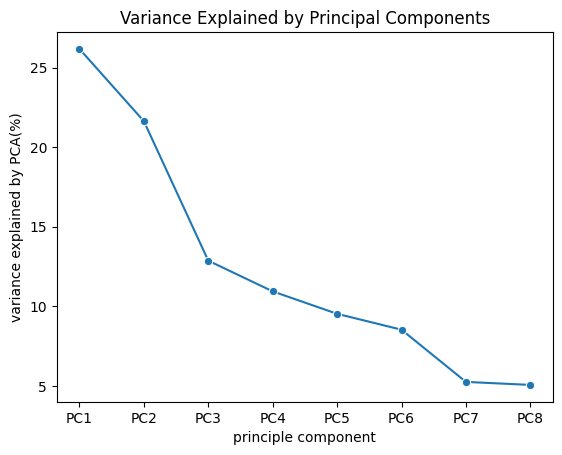

In [96]:
# screeplot
sns.lineplot(x = 'principle component', y = 'variance explained by PCA(%)', data = variance_table, marker = 'o')
plt.title('Variance Explained by Principal Components')
plt.show()

In [97]:
# loading matrix
loading_df = pd.DataFrame(pca5.components_.T, columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'], index = x.columns)
print(loading_df)

                               PC1       PC2       PC3       PC4       PC5
Pregnancies               0.128432  0.593786  0.013087  0.080691  0.475606
Glucose                   0.393083  0.174029 -0.467923 -0.404329 -0.466328
BloodPressure             0.360003  0.183892  0.535494  0.055986 -0.327953
SkinThickness             0.439824 -0.331965  0.237674  0.037976  0.487862
Insulin                   0.435026 -0.250781 -0.336709 -0.349944  0.346935
BMI                       0.451941 -0.100960  0.361865  0.053646 -0.253204
DiabetesPedigreeFunction  0.270611 -0.122069 -0.433189  0.833680 -0.119810
Age                       0.198027  0.620589 -0.075248  0.071201  0.109290


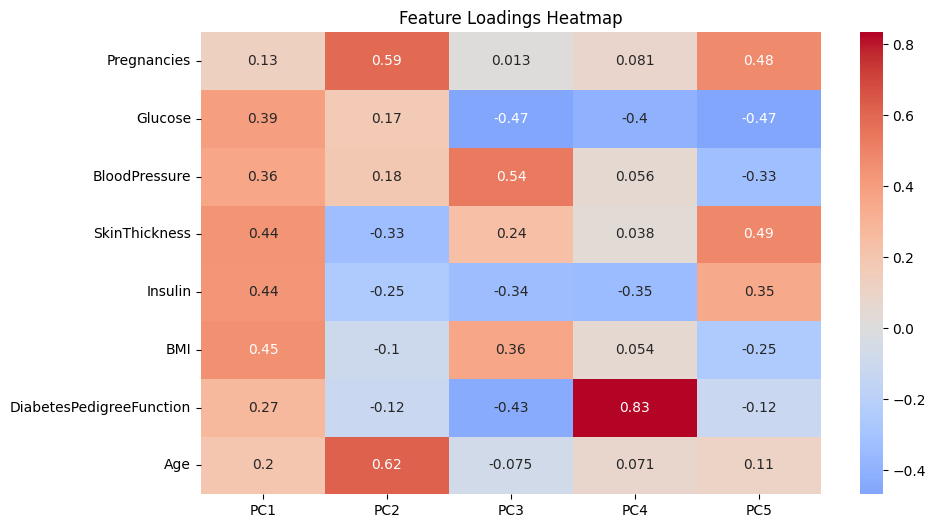

In [98]:
# heatmap of the loadings
plt.figure(figsize=(10, 6))
sns.heatmap(loadings_df, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Loadings Heatmap')
plt.show()

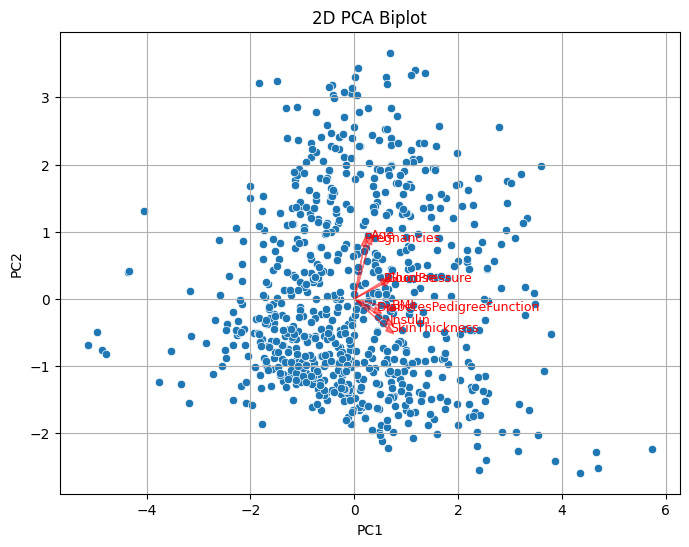

In [99]:
# considering first 2 principle components
pca2 = PCA(n_components = 2)
x_pca2 = pca2.fit_transform(x_scaled)

# biplot
fig = plt.figure(figsize=(8, 6))
sns.scatterplot(x = x_pca2[:, 0], y = x_pca2[:, 1])
plt.title('2D PCA Biplot')

# Extract eigenvalues
eigenvalues = np.sqrt(pca.explained_variance_)

# obtain loadings
scaled_loadings = pca.components_.T * eigenvalues

for i, feature in enumerate(feature_names):
    # arrows
    plt.arrow(0, 0, scaled_loadings[i, 0], scaled_loadings[i, 1],
              color='r', alpha=0.5, head_width=0.1)
    plt.text(scaled_loadings[i, 0]*1.1, scaled_loadings[i, 1]*1.1,
             feature, color='r', fontsize=9)

plt.xlabel(f'PC1')
plt.ylabel(f'PC2')
plt.grid(True)
plt.show()